In [ ]:
import matplotlib.pyplot as plt
import dask.array as da
from skimage.measure import label
import tifffile
import skimage as ski
import pandas as pd
import os
import numpy as np
from scipy import ndimage as ndi
import segment_functions as fun
import importlib
importlib.reload(fun)


<module 'segment_functions' from '/Users/hannahbolen/Desktop/image_analysis/whole_slide/segment_functions.py'>

In [34]:
# read in image
root = "/Users/hannahbolen/Desktop/image_analysis/"
img_name = "o8p_day7_s12.ome.tif"
img_path = os.path.join(root, img_name)
img = da.from_array(tifffile.imread(img_path))
# assign channels
nuclei = img[0]
cy5 = img[1]
# constants -- display
ds = 10
H, W = nuclei.shape
y0 = H//2 - 5120 # underlying "tile" size of 512, make tile excerpt multiple of 512
x0 = W//2 - 5120
# make tile from center of image
nucleiTile = nuclei[y0:y0+5120, x0:x0+5120]
cy5Tile = cy5[y0:y0+5120, x0:x0+5120]
# make even smaller tile
nucleiZoom = nucleiTile[1000:3000, 2000:4000]
cy5Zoom = cy5Tile[1000:3000, 2000:4000]

In [3]:
# constants -- processing
umPerPx = 0.325
nucleiThreshold = 50
nucleiMin = 150/umPerPx**2
nucleiMax = 12000
nucleiMean = 300/umPerPx**2
smooth=3
# function to visualize
def compare_segmentation(base,**images):
    plt.figure(figsize = (18,18))
    plt.subplot(2, 3, 1)
    plt.axis('off')
    plt.imshow(base, cmap = "gray")
    plt.title("nuclei")
    for i, img in enumerate(images.keys(), start=2):
        plt.subplot(2,3,i)
        plt.title(img)
        plt.imshow(images[img])
        plt.axis('off')
        plt.tight_layout()
    plt.show()

In [4]:
importlib.reload(fun)

<module 'segment_functions' from '/Users/hannahbolen/Desktop/image_analysis/whole_slide/segment_functions.py'>

In [12]:
threshold = 7
mask = ski.util.img_as_ubyte(ski.filters.gaussian(nucleiZoom, sigma = 1.8)) >= threshold
mask = ski.morphology.remove_small_objects(mask, min_size=nucleiMin)
labeled = ski.measure.label(mask)
labeled = fun.filter_by_region(labeled, threshold=lambda x: nucleiThreshold, intensity_image=nucleiZoom) > 0
filled = ndi.binary_fill_holes(labeled)
difference = ski.measure.label(filled != labeled)
change = fun.filter_by_region(difference, score=lambda r: r.area < nucleiMin, threshold=0) > 0
labeled[change] = filled[change]
nuclei = fun.apply_watershed(labeled,smooth=4)
result = fun.filter_by_region(nuclei, score=lambda r: nucleiMin < r.area < nucleiMax, threshold=nucleiThreshold)
boundaries = ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(nucleiZoom,in_range = (256, 12000)), result, mode="thick")

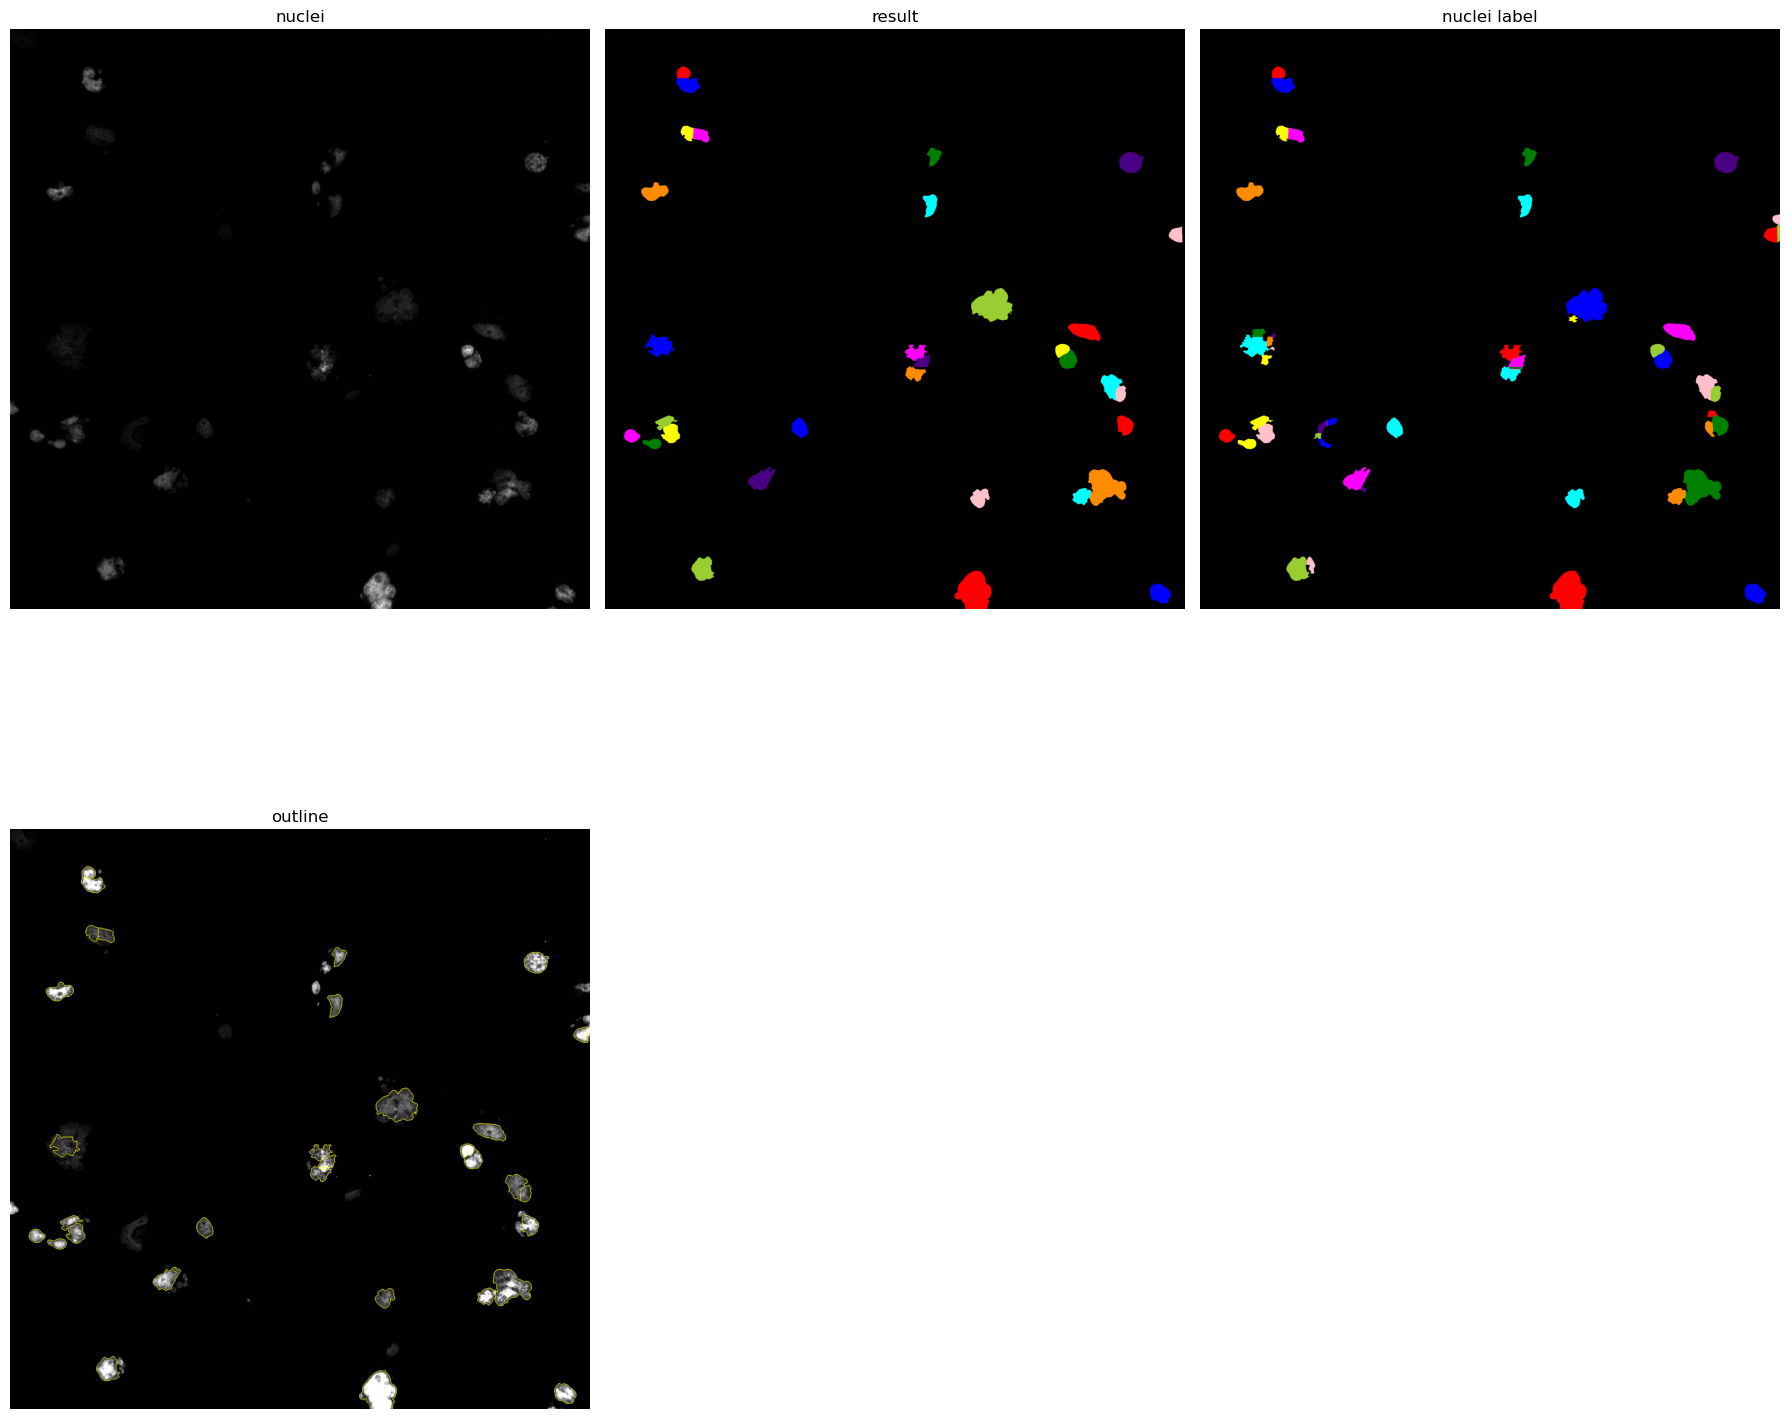

In [6]:
images = {"result":ski.color.label2rgb(result), "nuclei label":ski.color.label2rgb(nuclei), "outline":boundaries}
compare_segmentation(nucleiZoom,**images)

In [35]:
importlib.reload(fun)
fun.OPS_PROFILE = True
fun.OPS_PROFILE_VERBOSE = True
fun.ops_timing_reset()
kwargs = dict(threshold=lambda x: nucleiThreshold, 
            area_min=nucleiMin, area_max=nucleiMax,
            smooth=smooth)
findNuclei = fun.find_nuclei(nuclei, **kwargs)
fun.ops_timing_summary()

[ops_timer] simple_binary: 51.367s
[ops_timer] label: 2.960s
[ops_timer] filter_by_region_initial: 27.641s
[ops_timer] fill_holes: 33.183s
[ops_timer] label_hole_diff: 3.086s
[ops_timer] filter_by_region_holes: 25.268s
[ops_timer] apply_hole_fill: 0.961s
[ops_timer] watershed: 95.687s


KeyboardInterrupt: 

In [25]:

ops.OPS_PROFILE = True
ops.OPS_PROFILE_VERBOSE = True
ops.ops_timing_reset()
kwargs = dict(threshold=lambda x: nucleiThreshold, 
            area_min=nucleiMin, area_max=nucleiMax,
            smooth=smooth)
findNuclei = ops.find_nuclei(nucleiZoom, **kwargs)

[ops_timer] binarize: 0.504s
[ops_timer] label: 0.006s
[ops_timer] filter_by_region_initial: 0.171s
[ops_timer] fill_holes: 0.053s
[ops_timer] label_hole_diff: 0.008s
[ops_timer] filter_by_region_holes: 0.049s
[ops_timer] apply_hole_fill: 0.003s
[ops_timer] watershed: 0.219s
[ops_timer] filter_by_region_final: 0.048s


In [42]:
import dask_image


In [38]:
def simple_binary(image, min_size, sigma = 1.8, global_threshold = 7):
    mask = ski.util.img_as_ubyte(dask_image.ndfilters.gaussian(image, sigma)) >= global_threshold
    mask = ski.morphology.remove_small_objects(mask, min_size)
    return mask

In [43]:
dask_image.ndmorph

AttributeError: module 'dask_image' has no attribute 'ndmorph'